In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
df = pd.read_csv('SalesData.csv', encoding = 'unicode_escape')

In [5]:
df.shape

(11251, 15)

In [6]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


### Data Cleaning

In [8]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [9]:
pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
pd.isnull(df).sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [12]:
df['Amount']=df['Amount'].astype(int)

In [13]:
df['Amount'].dtype

dtype('int64')

In [14]:
df[['Amount','Orders']].describe()

,Amount,Orders
count,11239.000000,11239.000000
mean,9453.610553,2.489634
std,5222.355168,1.114967
min,188.000000,1.000000
25%,5443.000000,2.000000
50%,8109.000000,2.000000
75%,12675.000000,3.000000
max,23952.000000,4.000000


In [16]:
df.to_csv(r"C:\Users\hppc5\Downloads\SalesData_Clean.csv",
          index=False,
          encoding="utf-8",
          lineterminator="\n")

### Exploratory Data Analysis

#### Gender

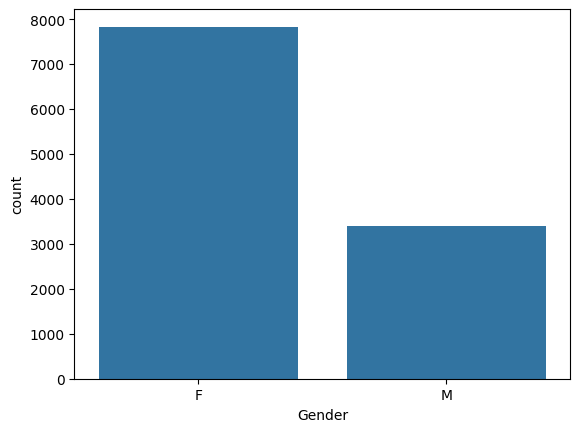

In [18]:
gender_graph = sns.countplot(x='Gender',data=df)
for bars in gender_graph.containers:
    ax.bar_label(bars)

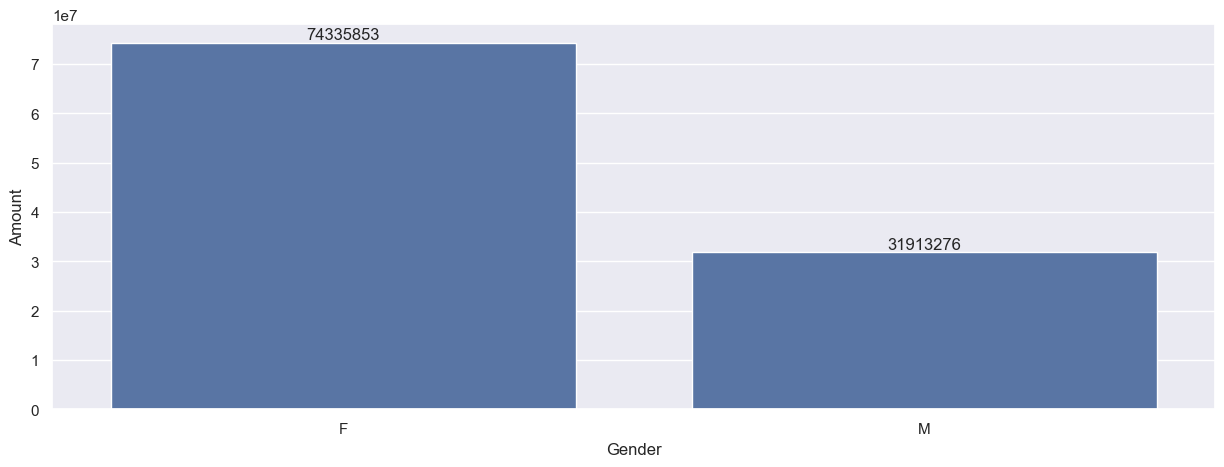

In [34]:
#Total amt vs Gender

sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
ax = sns.barplot(x='Gender',y='Amount',data=sales_gen)
for bars in ax.containers:
    ax.bar_label(bars,fmt='%.0f')

###### From above graph we can see most of the sales are from females.

#### Age

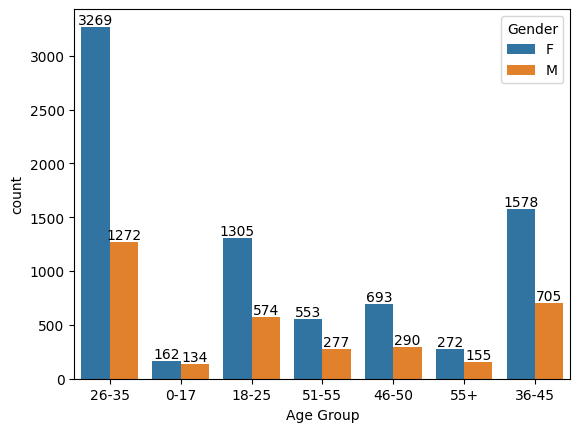

In [29]:
a = sns.countplot(data = df, x= 'Age Group', hue= 'Gender')
for bars in a.containers:
    a.bar_label(bars)

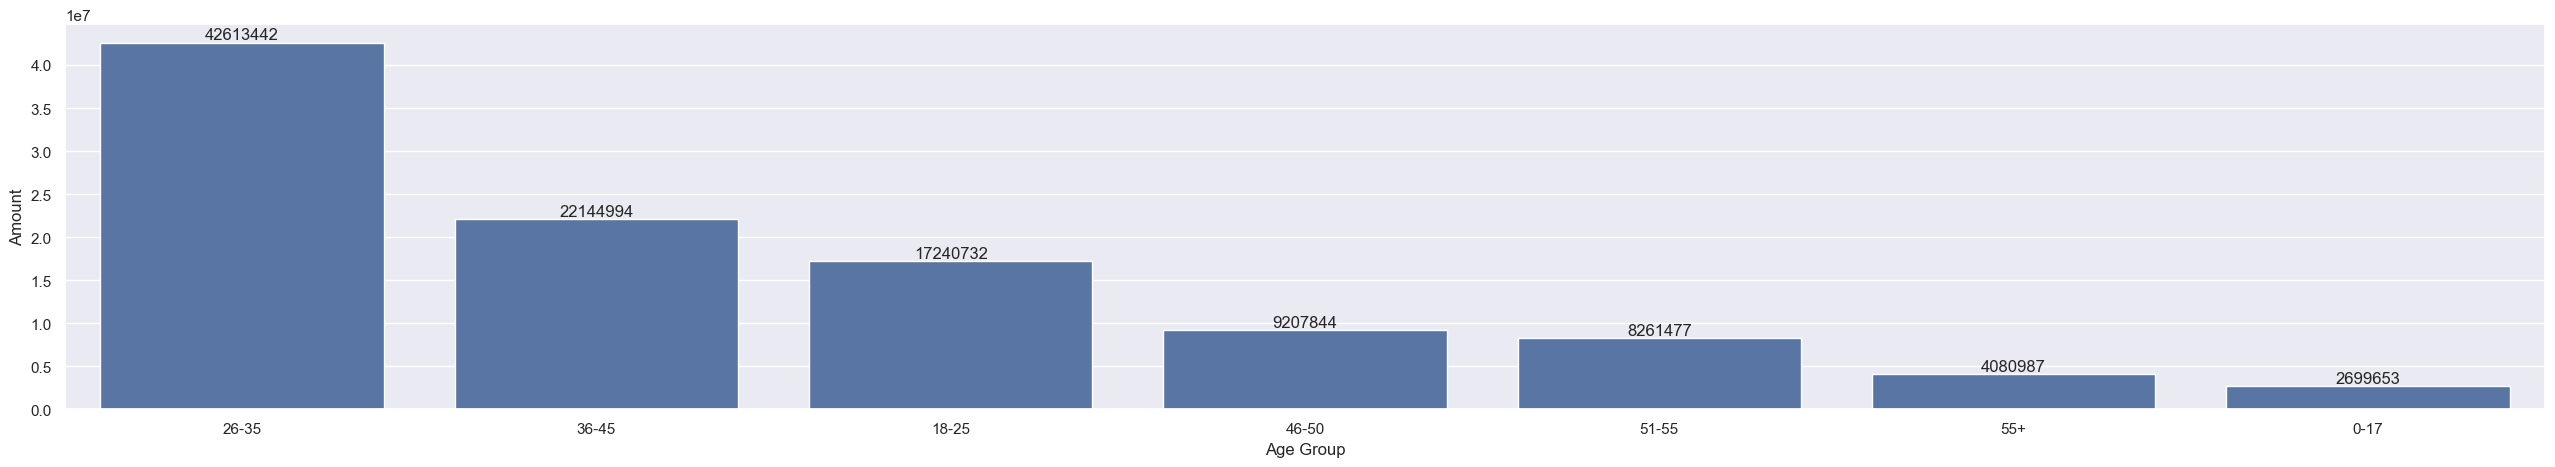

In [70]:
#Total amt vs Age grp

sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
ab = sns.barplot(x='Age Group',y='Amount',data=sales_age)
for bars in ab.containers:
    ab.bar_label(bars,fmt='%.0f')

###### from above graph we can see most of the buyers are from the 26-35 age grp.

#### Marital Status

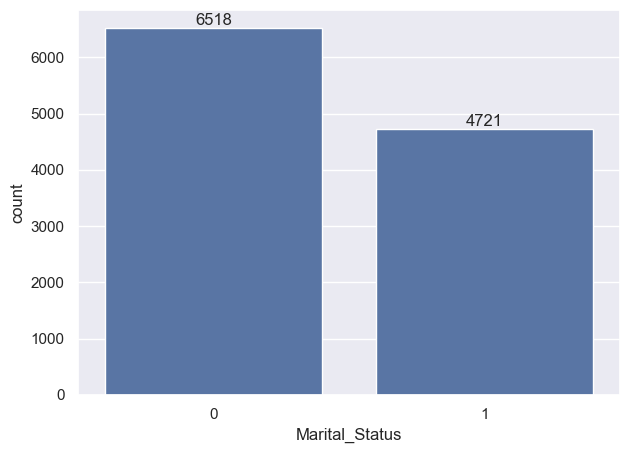

In [28]:
am = sns.countplot(data = df, x= 'Marital_Status')
for bars in am.containers:
    am.bar_label(bars)

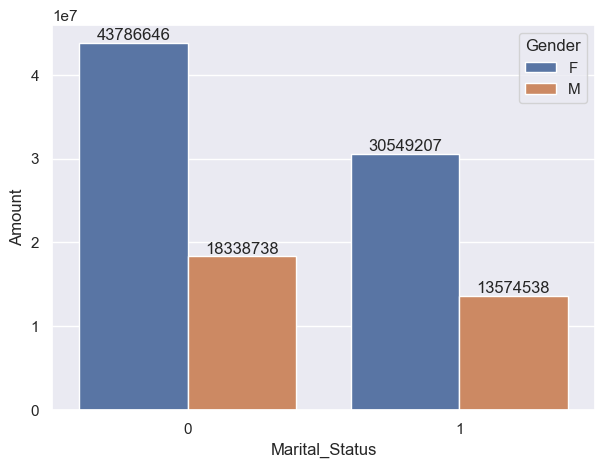

In [39]:
#Total no. of sales/amount from married/unmarried people.

sales_state = df.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.set(rc={'figure.figsize':(7,5)})
pg=sns.barplot(data=sales_state, x='Marital_Status', y='Amount',hue='Gender')
for bars in pg.containers:
    pg.bar_label(bars, fmt='%.0f')

###### From the above graphs we can see that most of the buyers with high purchasing power are married women.

#### State

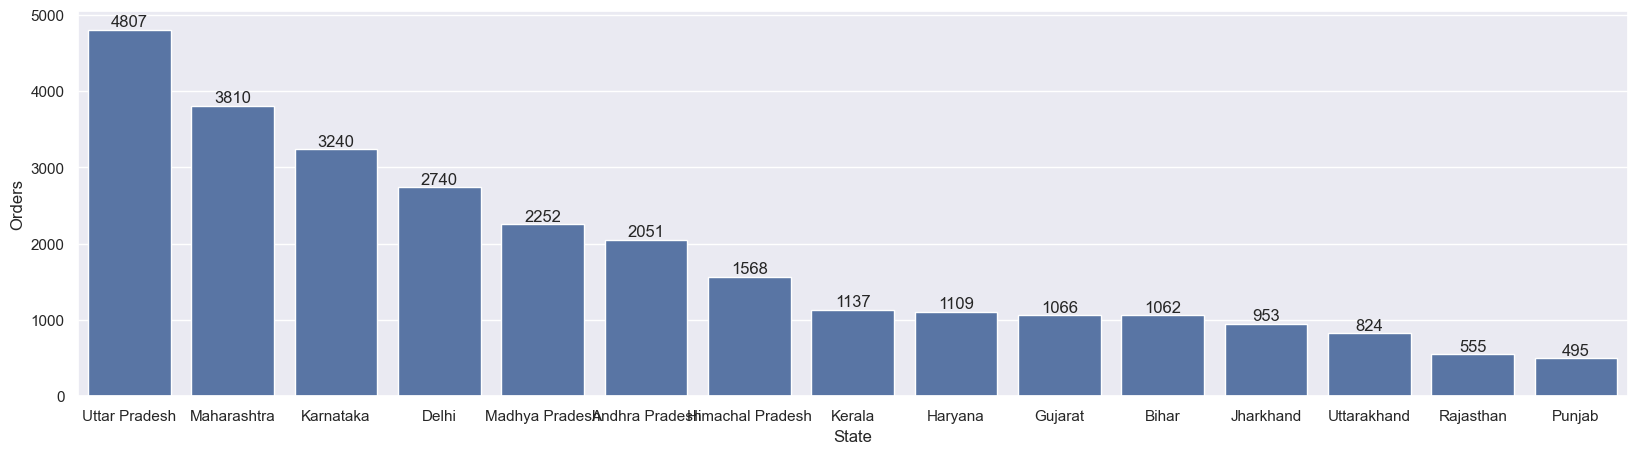

In [38]:
#Total no. of orders from top 15 states

sales_state = df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(15)
sns.set(rc={'figure.figsize':(20,5)})
ps=sns.barplot(data=sales_state, x='State', y='Orders')
for bars in ps.containers:
    ps.bar_label(bars, fmt='%.0f')

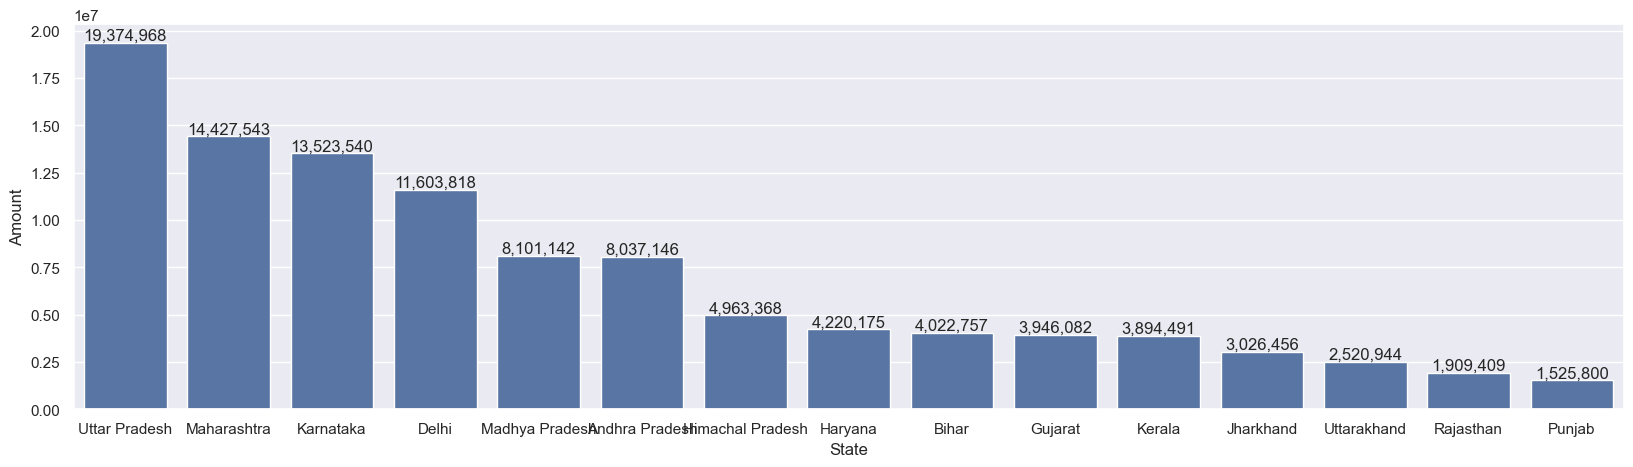

In [31]:
#Total amt/sales from top 15 states

sale_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(15)
plt.figure(figsize=(20,5))
ax = sns.barplot(data=sale_state, x='State', y='Amount')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
plt.show()

###### From these graphs we can see that most of the orders and sales/amount are from Uttar Pradesh, Maharashtra, karnataka respectively.

#### Occupation

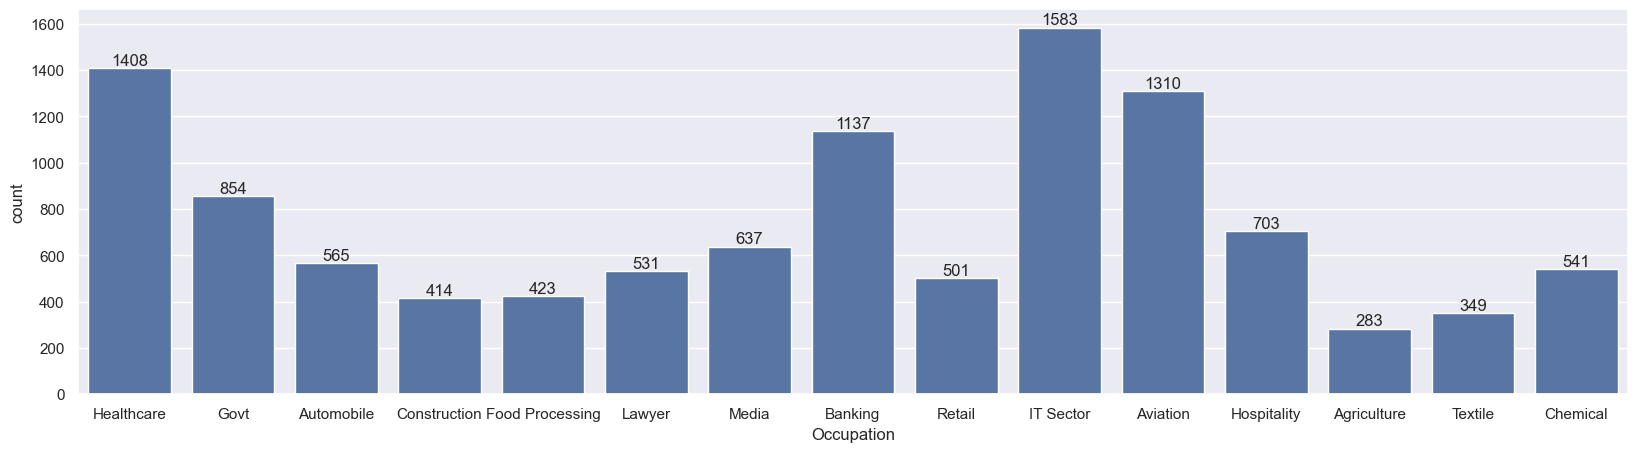

In [42]:
sns.set(rc={'figure.figsize':(20,5)})
occ=sns.countplot(data=df, x='Occupation')
for bars in occ.containers:
    occ.bar_label(bars)

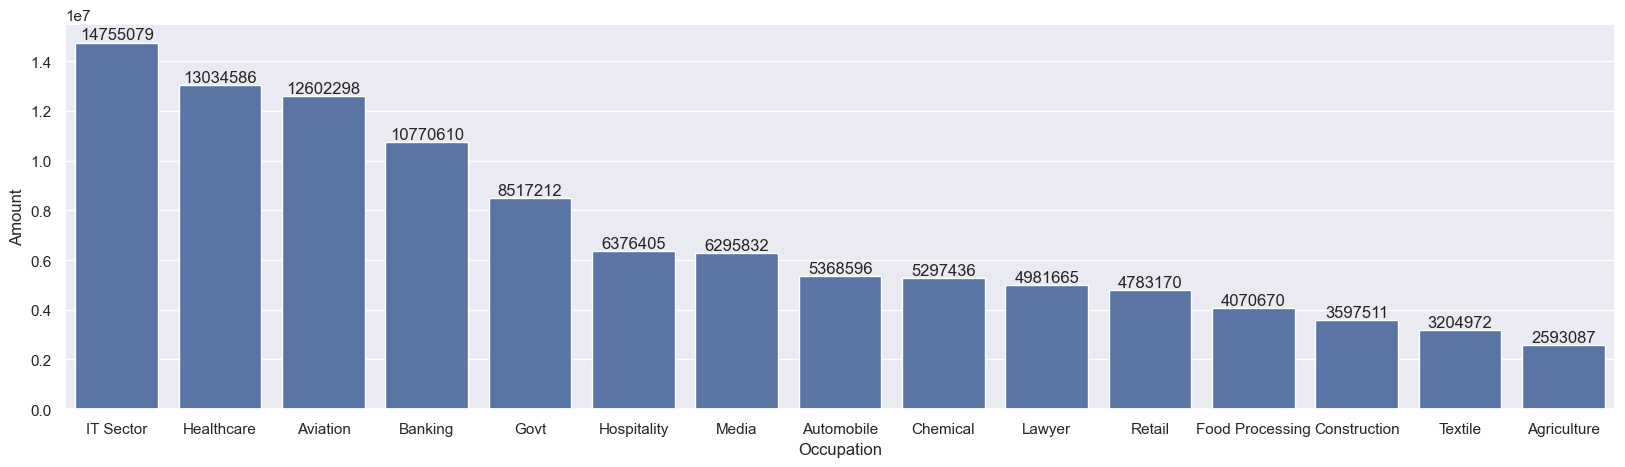

In [34]:
#Total sales/amount by Occupation of people

sales_occ = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.barplot(data=sales_occ, x='Occupation', y='Amount')
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.0f')

###### From the above graph we can see that most of the buyers are from IT, Healthcare, and Aviation sector.

In [46]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

#### Product Category

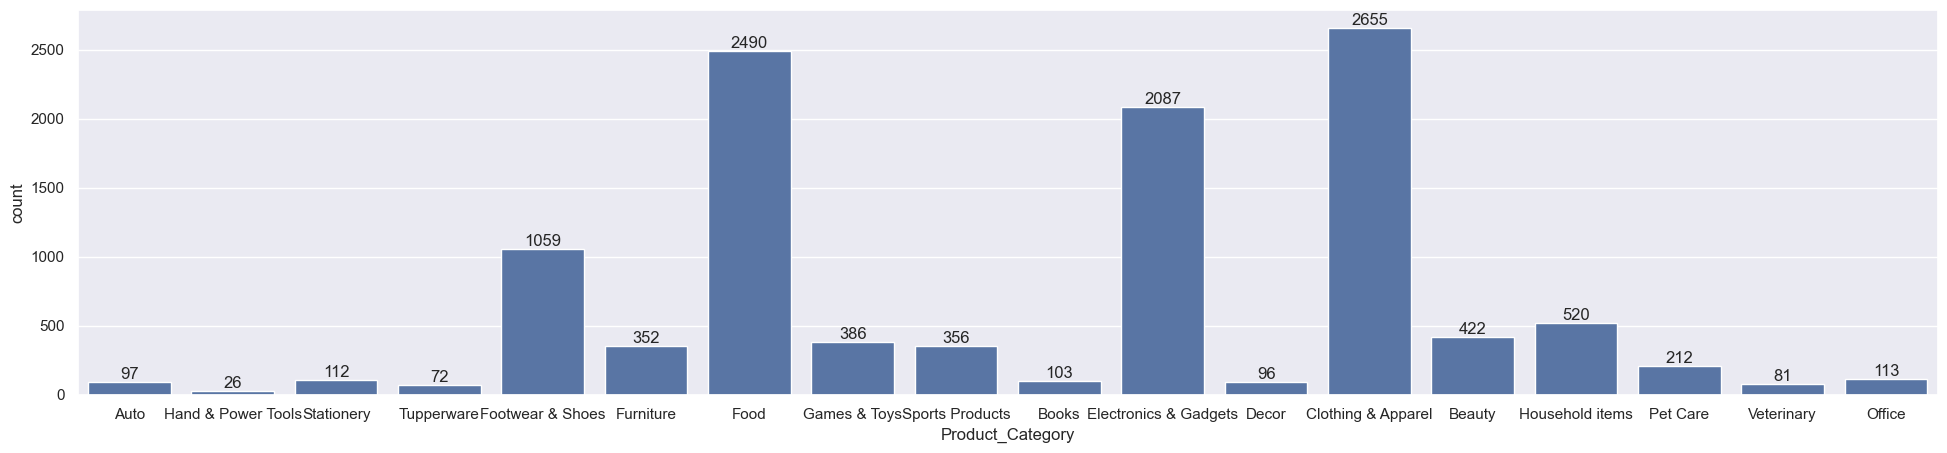

In [50]:
sns.set(rc={'figure.figsize':(24,5)})
occ=sns.countplot(data=df, x='Product_Category')
for bars in occ.containers:
    occ.bar_label(bars)

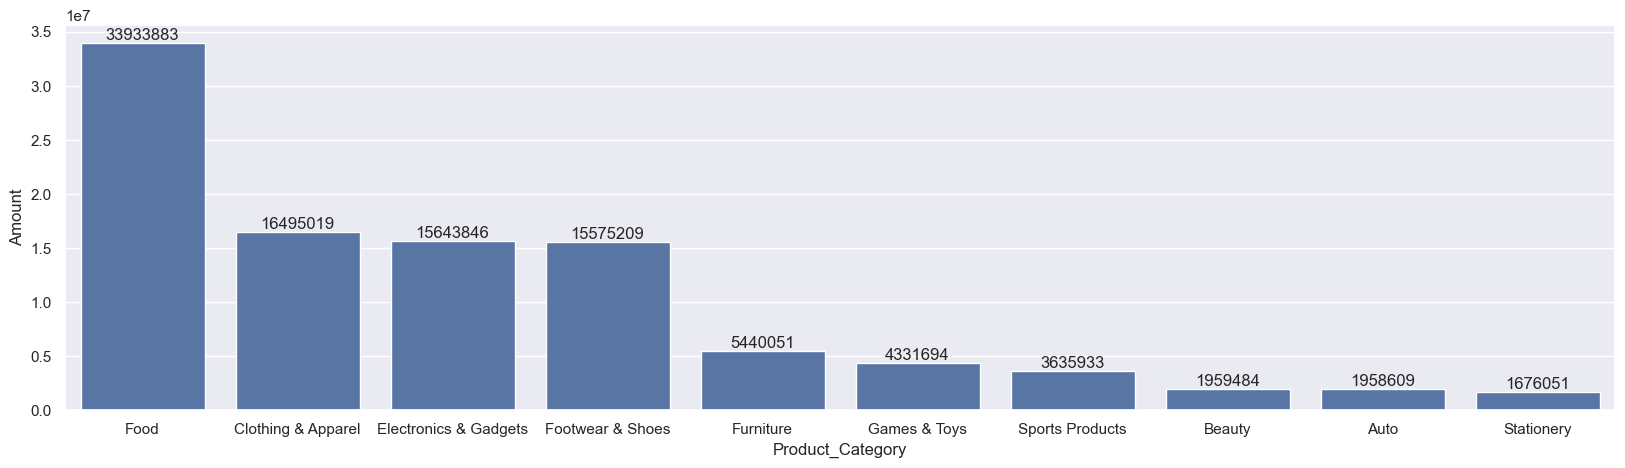

In [36]:
#Total sales/amount by Products category

sales_pc = df.groupby(['Product_Category'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(20,5)})
pc= sns.barplot(data=sales_pc, x='Product_Category', y='Amount')
for bars in pc.containers:
    pc.bar_label(bars, fmt='%.0f')

###### From above graph we can see that most of the sold products are from food, clothing & apparel, and electronics & gadgets category.

#### Product ID

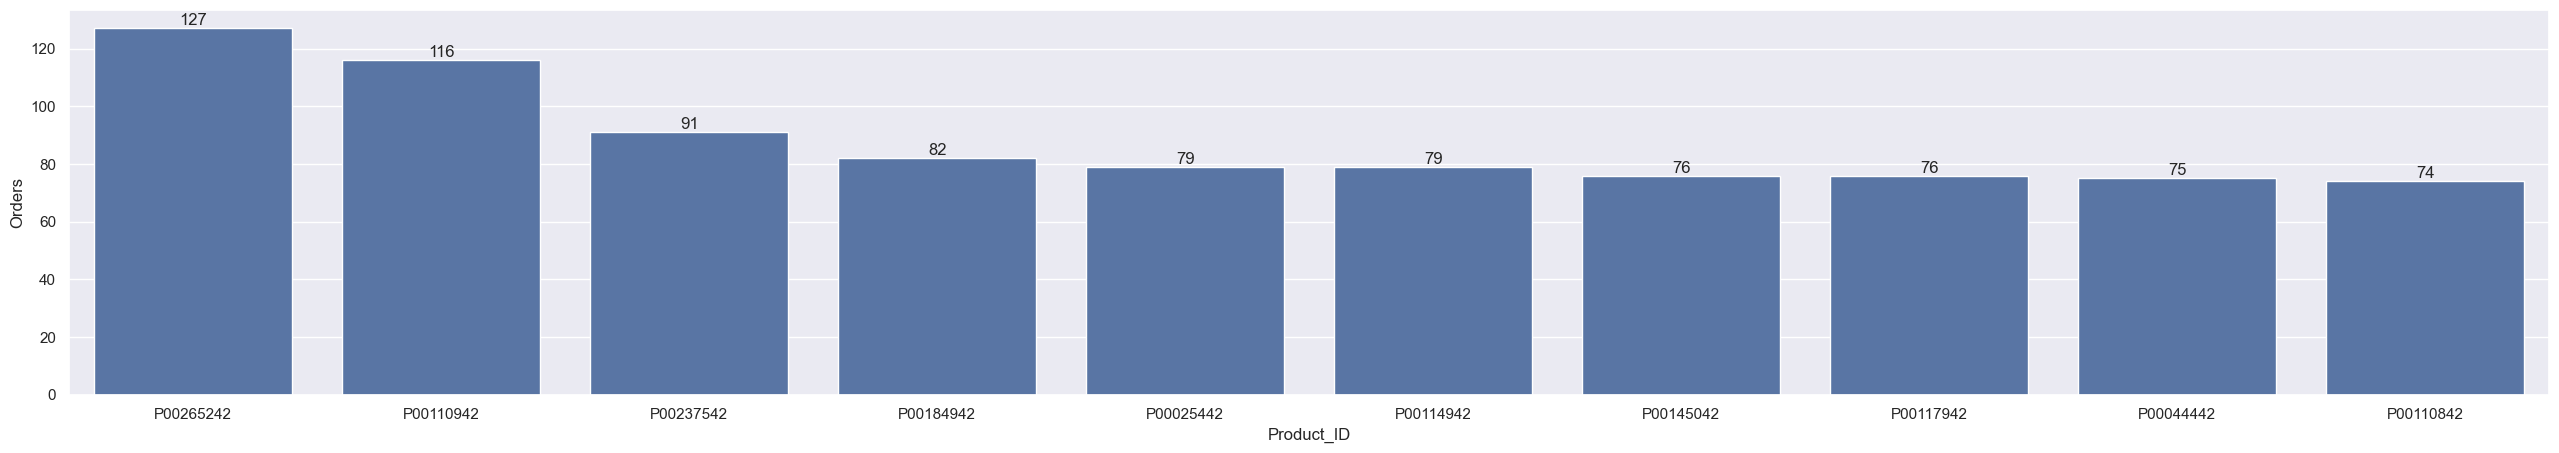

In [40]:
#Total sales/amount by Products ID(top IDs)

sales_pID = df.groupby(['Product_ID'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)
sns.set(rc={'figure.figsize':(32,5)})
pID=sns.barplot(data=sales_pID, x='Product_ID', y='Orders')
for bars in pID.containers:
    pID.bar_label(bars, fmt='%.0f')

#### Conclusion

##### Female from 26-35 age group from UP, Maharashtra, and Karnataka from IT, Healthcare, and Aviation are more likely to buy products from food, electronics, and clothing category.